In [6]:
import sys
import torch
import torchvision

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Python: d:\eye disease classification datasets\venv\Scripts\python.exe
PyTorch: 2.7.1+cu118
TorchVision: 0.22.1+cu118
CUDA available: True
Device: NVIDIA GeForce RTX 2050


In [7]:
# 1. Import libraries and define reproducible configuration
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm.auto import tqdm

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
DATA_DIR = Path("eye_disease")
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMAGE_SIZE = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 32
NUM_WORKERS = 0

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR.resolve()}")

CLASS_NAMES = sorted(folder.name for folder in DATA_DIR.iterdir() if folder.is_dir())
NUM_CLASSES = len(CLASS_NAMES)
print(f"Dataset: {DATA_DIR.resolve()}")
print(f"Classes: {CLASS_NAMES}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Device: {DEVICE}")
if CUDA_AVAILABLE:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CUDA is not available; training will run on CPU.")


Dataset: D:\eye disease classification datasets\eye_disease
Classes: ['glaucoma', 'normal']
Number of classes: 2
Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [8]:
# 2. Build a stratified file-level train/validation/test split
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
records = []

for class_index, class_name in enumerate(CLASS_NAMES):
    class_files = [
        path for path in (DATA_DIR / class_name).rglob("*")
        if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS
    ]
    records.extend(
        {"filepath": str(path), "label": class_index, "class_name": class_name}
        for path in class_files
    )

dataframe = pd.DataFrame(records)
if dataframe.empty:
    raise ValueError(f"No supported image files found under {DATA_DIR.resolve()}")

train_df, temp_df = train_test_split(
    dataframe, test_size=0.30, stratify=dataframe["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print(f"Total images: {len(dataframe)}")
print(f"Train: {len(train_df)}, validation: {len(val_df)}, test: {len(test_df)}")
print("\nClass distribution before balancing:")
print(dataframe["class_name"].value_counts().sort_index())

Total images: 1183
Train: 828, validation: 177, test: 178

Class distribution before balancing:
class_name
glaucoma    568
normal      615
Name: count, dtype: int64


In [9]:
# 2b. Save the stratified train, validation, and test splits as CSV files
SPLIT_CSV_DIR = DATA_DIR.parent / "dataset_splits"
SPLIT_CSV_DIR.mkdir(parents=True, exist_ok=True)

train_csv = SPLIT_CSV_DIR / "train.csv"
validation_csv = SPLIT_CSV_DIR / "validation.csv"
test_csv = SPLIT_CSV_DIR / "test.csv"
train_df.to_csv(train_csv, index=False)
val_df.to_csv(validation_csv, index=False)
test_df.to_csv(test_csv, index=False)

print(f"Training CSV: {train_csv} ({len(train_df)} images)")
print(f"Validation CSV: {validation_csv} ({len(val_df)} images)")
print(f"Testing CSV: {test_csv} ({len(test_df)} images)")

Training CSV: dataset_splits\train.csv (828 images)
Validation CSV: dataset_splits\validation.csv (177 images)
Testing CSV: dataset_splits\test.csv (178 images)


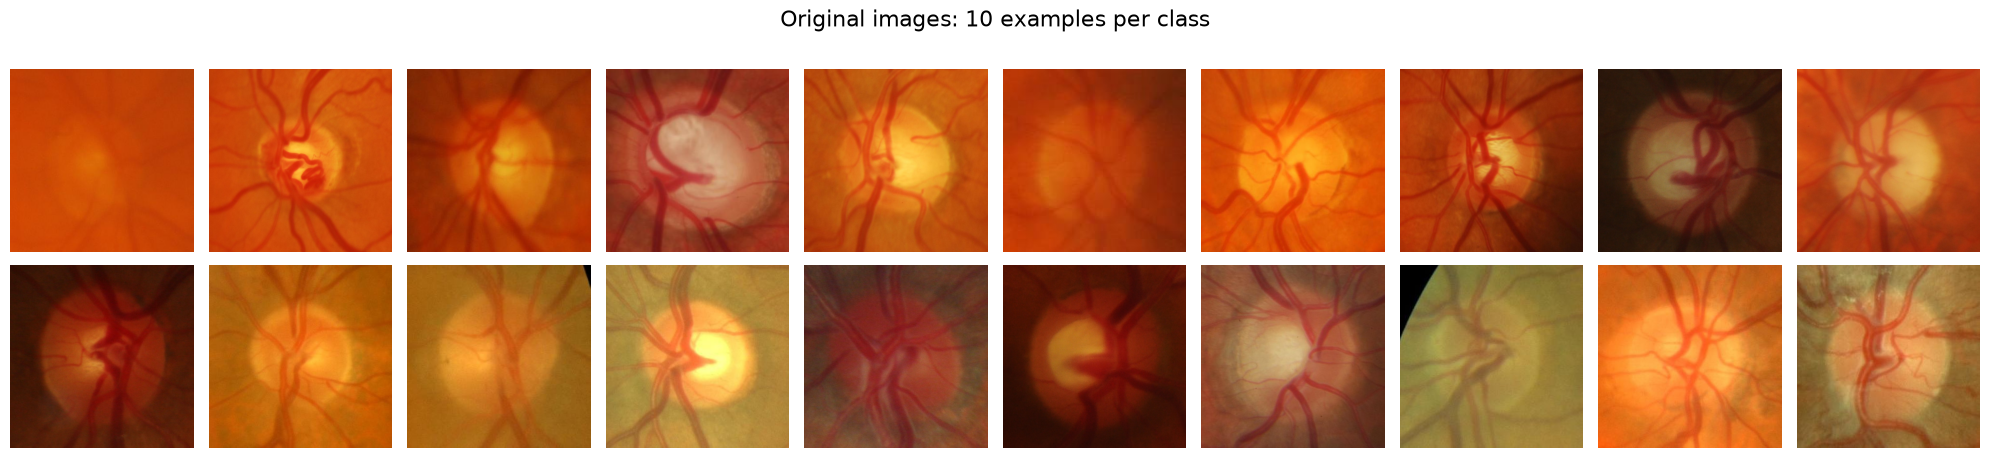

In [10]:
# 3. Visualize 10 images from every class
num_images_per_class = 10
fig, axes = plt.subplots(
    NUM_CLASSES,
    num_images_per_class,
    figsize=(20, 2.4 * NUM_CLASSES),
    squeeze=False,
)

for row, class_name in enumerate(CLASS_NAMES):
    class_files = [
        path for path in (DATA_DIR / class_name).rglob("*")
        if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS
    ]
    sample_files = random.sample(class_files, min(num_images_per_class, len(class_files)))

    for col in range(num_images_per_class):
        axis = axes[row, col]
        axis.axis("off")
        if col < len(sample_files):
            with Image.open(sample_files[col]) as image:
                axis.imshow(image.convert("RGB"))
        if col == 0:
            axis.set_ylabel(class_name, fontsize=12)

plt.suptitle("Original images: 10 examples per class", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
# 4. Use the complete training split without undersampling or synthetic augmentation
balanced_train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print("Training distribution without undersampling:")
print(balanced_train_df["class_name"].value_counts().sort_index())
print(f"Total training images: {len(balanced_train_df)}")

Training distribution without undersampling:
class_name
glaucoma    398
normal      430
Name: count, dtype: int64
Total training images: 828


In [12]:
# 5. Resize RGB images and apply Lab-channel CLAHE
IMAGE_SIZE = (224, 224)


def apply_clahe_rgb(rgb_image, clip_limit=2.0, grid_size=(8, 8)):
    rgb_image = np.clip(np.asarray(rgb_image), 0, 255).astype(np.uint8)
    lab_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)
    lightness, a_channel, b_channel = cv2.split(lab_image)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    enhanced_lightness = clahe.apply(lightness)
    enhanced_lab = cv2.merge((enhanced_lightness, a_channel, b_channel))
    return cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)


class EyeDiseaseDataset(Dataset):
    def __init__(self, frame, training=False):
        self.frame = frame.reset_index(drop=True)
        self.training = training
        self.augmentation = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(8),
            transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
            transforms.ColorJitter(contrast=0.10, brightness=0.08),
        ])
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.filepath) as image:
            image = image.convert("RGB")
        image = image.resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
        image = Image.fromarray(apply_clahe_rgb(np.asarray(image)))
        if self.training:
            image = self.augmentation(image)
        tensor = self.normalize(self.to_tensor(image))
        return tensor, int(row.label)


def build_loader(frame, training=False):
    return DataLoader(
        EyeDiseaseDataset(frame, training=training),
        batch_size=BATCH_SIZE,
        shuffle=training,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


train_loader = build_loader(balanced_train_df, training=True)
val_loader = build_loader(val_df)
test_loader = build_loader(test_df)
print("PyTorch CLAHE-enhanced image pipeline ready")
print(f"Image size: {IMAGE_SIZE}")

PyTorch CLAHE-enhanced image pipeline ready
Image size: (224, 224)


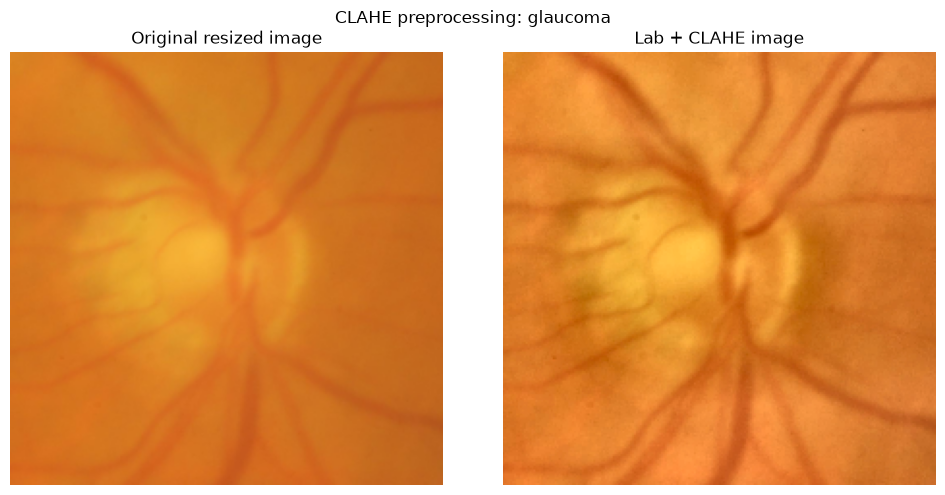

In [13]:
# 5b. Visualize the original image and its CLAHE-enhanced version
sample_path = Path(dataframe.iloc[0]["filepath"])
sample_bgr = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)
if sample_bgr is None:
    raise ValueError(f"Could not read image: {sample_path}")
sample_rgb = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB)
sample_resized = cv2.resize(sample_rgb, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
sample_clahe = apply_clahe_rgb(sample_resized)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_resized)
axes[0].set_title("Original resized image")
axes[1].imshow(sample_clahe)
axes[1].set_title("Lab + CLAHE image")
for axis in axes:
    axis.axis("off")
fig.suptitle(f"CLAHE preprocessing: {sample_path.parent.name}")
plt.tight_layout()
plt.show()

In [14]:
# 6. Trainable pretrained MobileNetV2 classifier
weights = models.MobileNet_V2_Weights.DEFAULT
mobilenet_backbone = models.mobilenet_v2(weights=weights)
feature_count = mobilenet_backbone.classifier[1].in_features
mobilenet_backbone.classifier = nn.Sequential(
    nn.Dropout(0.50),
    nn.Linear(feature_count, 64),
    nn.ReLU(inplace=True),
    nn.Dropout(0.50),
    nn.Linear(64, NUM_CLASSES),
)
model = mobilenet_backbone.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.10)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=4, min_lr=1e-7
)

print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Current device: {DEVICE}")

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [15]:
# 7. Train the PyTorch MobileNetV2 model and save checkpoints
MODEL_OUTPUT_DIR = DATA_DIR.parent / "saved_models"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = MODEL_OUTPUT_DIR / "mobilenetv2_best.pt"
FINAL_MODEL_PATH = MODEL_OUTPUT_DIR / "mobilenetv2_final.pt"
EPOCHS = 60
PATIENCE = 8


def run_epoch(loader, training=False):
    model.train(training)
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val_accuracy = -1.0
epochs_without_improvement = 0
for epoch in range(EPOCHS):
    train_loss, train_accuracy = run_epoch(train_loader, training=True)
    val_loss, val_accuracy = run_epoch(val_loader)
    scheduler.step(val_loss)
    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} - "
        f"loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f} - "
        f"val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}"
    )
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_without_improvement = 0
        torch.save({"model_state": model.state_dict(), "class_names": CLASS_NAMES}, BEST_MODEL_PATH)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping")
            break

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state"])
torch.save({"model_state": model.state_dict(), "class_names": CLASS_NAMES}, FINAL_MODEL_PATH)
print(f"Best model saved to: {BEST_MODEL_PATH}")
print(f"Final model saved to: {FINAL_MODEL_PATH}")

Epoch 01/60 - loss: 0.6151 - accuracy: 0.7101 - val_loss: 0.5070 - val_accuracy: 0.7571
Epoch 02/60 - loss: 0.4126 - accuracy: 0.8684 - val_loss: 0.3835 - val_accuracy: 0.8983
Epoch 03/60 - loss: 0.3577 - accuracy: 0.9058 - val_loss: 0.3670 - val_accuracy: 0.8870
Epoch 04/60 - loss: 0.3412 - accuracy: 0.9155 - val_loss: 0.3680 - val_accuracy: 0.8927
Epoch 05/60 - loss: 0.3079 - accuracy: 0.9384 - val_loss: 0.3340 - val_accuracy: 0.9153
Epoch 06/60 - loss: 0.2800 - accuracy: 0.9674 - val_loss: 0.3591 - val_accuracy: 0.9209
Epoch 07/60 - loss: 0.2637 - accuracy: 0.9662 - val_loss: 0.3752 - val_accuracy: 0.9209
Epoch 08/60 - loss: 0.2533 - accuracy: 0.9734 - val_loss: 0.3715 - val_accuracy: 0.9209
Epoch 09/60 - loss: 0.2480 - accuracy: 0.9807 - val_loss: 0.3721 - val_accuracy: 0.9040
Epoch 10/60 - loss: 0.2414 - accuracy: 0.9903 - val_loss: 0.3612 - val_accuracy: 0.9040
Epoch 11/60 - loss: 0.2334 - accuracy: 0.9879 - val_loss: 0.3348 - val_accuracy: 0.9153
Epoch 12/60 - loss: 0.2289 - acc

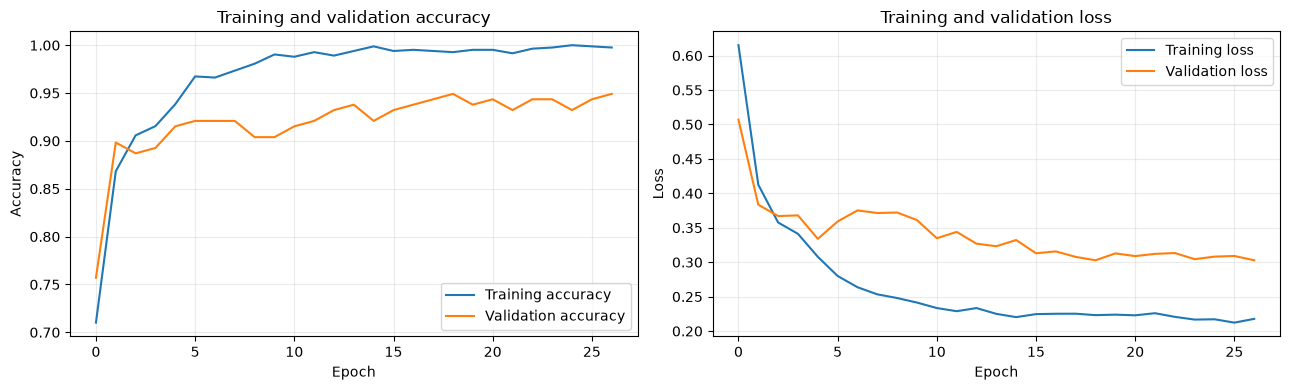

   class  sensitivity  precision  f1_score  support
glaucoma     0.976471   0.965116  0.970760       85
  normal     0.967742   0.978261  0.972973       93

Classification report:
              precision    recall  f1-score   support

    glaucoma       0.97      0.98      0.97        85
      normal       0.98      0.97      0.97        93

    accuracy                           0.97       178
   macro avg       0.97      0.97      0.97       178
weighted avg       0.97      0.97      0.97       178

AUC-ROC: 0.9923


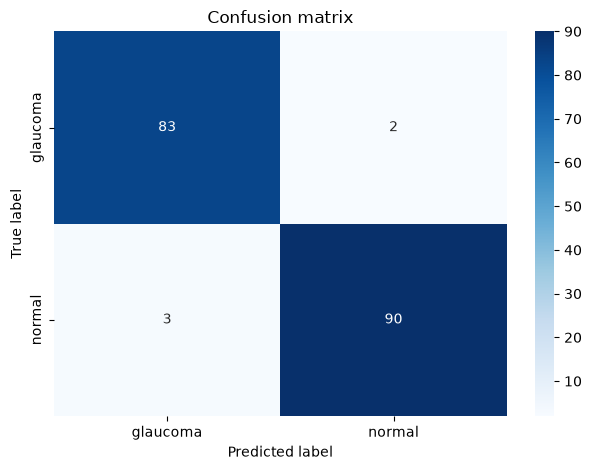

In [16]:
# 8. Plot training curves and evaluate the test set
history_frame = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_frame["accuracy"], label="Training accuracy")
axes[0].plot(history_frame["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Training and validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(history_frame["loss"], label="Training loss")
axes[1].plot(history_frame["val_loss"], label="Validation loss")
axes[1].set_title("Training and validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

model.eval()
true_labels, predicted_labels, predicted_probabilities = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        probabilities = torch.softmax(model(images.to(DEVICE)), dim=1).cpu().numpy()
        predicted_probabilities.append(probabilities)
        predicted_labels.extend(probabilities.argmax(axis=1))
        true_labels.extend(labels.numpy())
true_labels = np.asarray(true_labels)
predicted_labels = np.asarray(predicted_labels)
predicted_probabilities = np.concatenate(predicted_probabilities)

precision, recall, f1_score, support = precision_recall_fscore_support(
    true_labels, predicted_labels, labels=np.arange(NUM_CLASSES), zero_division=0
)
metrics_table = pd.DataFrame({
    "class": CLASS_NAMES, "sensitivity": recall, "precision": precision,
    "f1_score": f1_score, "support": support,
})
print(metrics_table.to_string(index=False))
print("\nClassification report:")
print(classification_report(
    true_labels, predicted_labels, labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES, zero_division=0,
))
auc_score = roc_auc_score(true_labels, predicted_probabilities[:, 1])
print(f"AUC-ROC: {auc_score:.4f}")
confusion = confusion_matrix(true_labels, predicted_labels, labels=np.arange(NUM_CLASSES))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

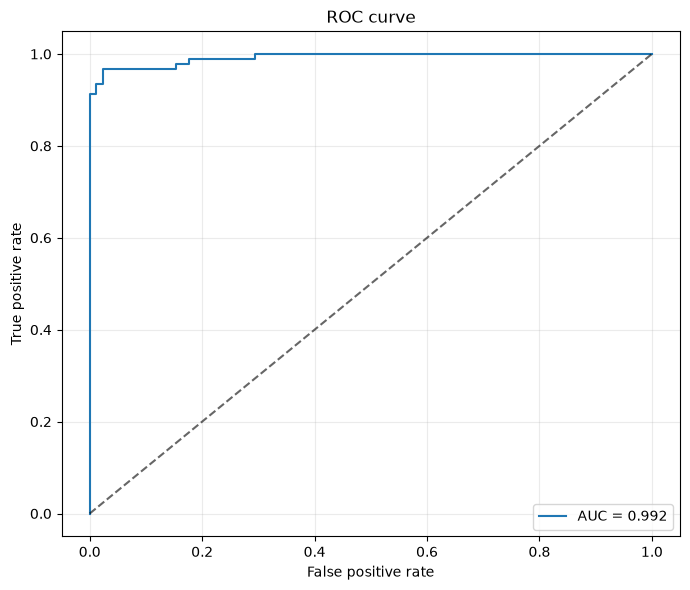

In [17]:
# 9. ROC curve for glaucoma versus normal
false_positive_rate, true_positive_rate, _ = roc_curve(true_labels, predicted_probabilities[:, 1])
plt.figure(figsize=(7, 6))
plt.plot(false_positive_rate, true_positive_rate, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [18]:
torch.save({"model_state": model.state_dict(), "class_names": CLASS_NAMES}, DATA_DIR.parent / "mobilenetv2_trained_model.pt")
print("Model saved successfully as a PyTorch checkpoint!")

Model saved successfully as a PyTorch checkpoint!


In [19]:
# Reload the saved MobileNetV2 checkpoint for inference
MODEL_CHECKPOINT_PATH = DATA_DIR.parent / "mobilenetv2_trained_model.pt"
checkpoint = torch.load(
    MODEL_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

loaded_class_names = checkpoint["class_names"]
loaded_model = models.mobilenet_v2(weights=None)
loaded_feature_count = loaded_model.classifier[1].in_features
loaded_model.classifier = nn.Sequential(
    nn.Dropout(0.50),
    nn.Linear(loaded_feature_count, 64),
    nn.ReLU(inplace=True),
    nn.Dropout(0.50),
    nn.Linear(64, len(loaded_class_names)),
)
loaded_model.load_state_dict(checkpoint["model_state"])
loaded_model = loaded_model.to(DEVICE)
loaded_model.eval()

print(f"Loaded model: {MODEL_CHECKPOINT_PATH}")
print(f"Classes: {loaded_class_names}")
print(f"Device: {DEVICE}")
print("Model is ready for inference.")

# Example, after the prediction function is defined:
# result = predict_new_image(
#     "eye_disease/glaucoma/Im479_g_ACRIMA.jpg",
#     trained_model=loaded_model,
# )
# print(result)

Loaded model: mobilenetv2_trained_model.pt
Classes: ['glaucoma', 'normal']
Device: cuda
Model is ready for inference.


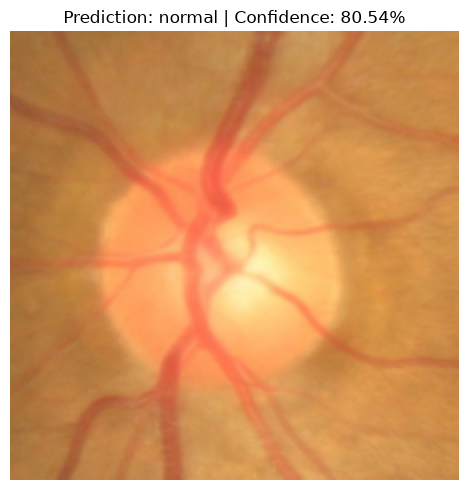

{'predicted_class': 'normal', 'confidence': 0.8054053783416748, 'probabilities': {'glaucoma': np.float64(0.194594606757164), 'normal': np.float64(0.8054053783416748)}}


In [20]:
# 10. Predict a new image with MobileNetV2

def preprocess_single_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
    image = Image.fromarray(apply_clahe_rgb(np.asarray(image)))
    tensor = transforms.ToTensor()(image)
    tensor = transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    )(tensor)
    return tensor.unsqueeze(0)


def predict_new_image(image_path, trained_model=None):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path.resolve()}")

    if trained_model is None:
        if "loaded_model" in globals():
            trained_model = loaded_model
        elif "model" in globals():
            trained_model = model
        else:
            raise RuntimeError(
                "No trained model is loaded. Run the checkpoint reload cell first."
            )

    class_names = loaded_class_names if "loaded_class_names" in globals() else CLASS_NAMES
    trained_model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(
            trained_model(preprocess_single_image(image_path).to(DEVICE)), dim=1
        )[0].cpu().numpy()
    predicted_index = int(np.argmax(probabilities))
    display_image = Image.open(image_path).convert("RGB").resize(IMAGE_SIZE)
    plt.figure(figsize=(5, 5))
    plt.imshow(display_image)
    plt.axis("off")
    plt.title(
        f"Prediction: {class_names[predicted_index]} | "
        f"Confidence: {probabilities[predicted_index] * 100:.2f}%"
    )
    plt.tight_layout()
    plt.show()
    return {
        "predicted_class": class_names[predicted_index],
        "confidence": float(probabilities[predicted_index]),
        "probabilities": dict(zip(class_names, probabilities.astype(float))),
    }


result = predict_new_image("g3.png")
print(result)

Predicting test images:   0%|          | 0/178 [00:00<?, ?it/s]

Predicted images: 178
Accuracy: 0.9719 (97.19%)
Confusion matrix [rows=true, columns=predicted]:
[[83  2]
 [ 3 90]]

Classification report:
              precision    recall  f1-score   support

    glaucoma       0.97      0.98      0.97        85
      normal       0.98      0.97      0.97        93

    accuracy                           0.97       178
   macro avg       0.97      0.97      0.97       178
weighted avg       0.97      0.97      0.97       178

Per-image predictions saved to: dataset_splits\test_predictions.csv


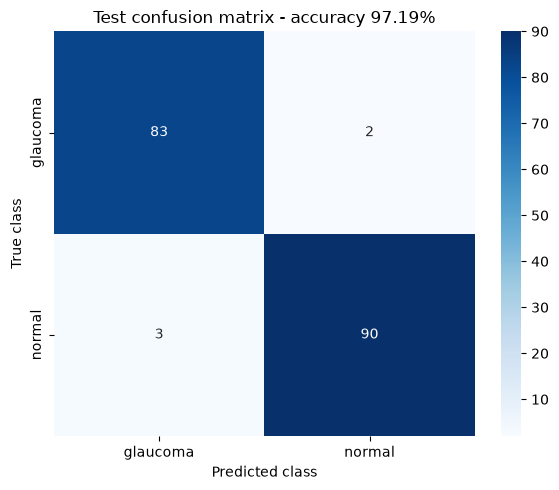

In [21]:
# 11. Predict test.csv images one by one and calculate evaluation metrics
TEST_CSV_PATH = DATA_DIR.parent / "dataset_splits" / "test.csv"
PREDICTIONS_CSV_PATH = DATA_DIR.parent / "dataset_splits" / "test_predictions.csv"
csv_test_df = pd.read_csv(TEST_CSV_PATH)


if "loaded_model" in globals():
    evaluation_model = loaded_model
    evaluation_class_names = loaded_class_names
elif "model" in globals():
    evaluation_model = model
    evaluation_class_names = CLASS_NAMES
else:
    raise RuntimeError("No trained model is loaded. Run the model training or reload cell first.")


def resolve_image_path(filepath):
    path = Path(filepath)
    if path.exists():
        return path
    candidate = DATA_DIR.parent / path
    if candidate.exists():
        return candidate
    raise FileNotFoundError(f"Test image not found: {filepath}")


prediction_rows = []
evaluation_model.eval()
for row in tqdm(csv_test_df.itertuples(index=False), total=len(csv_test_df), desc="Predicting test images"):
    image_path = resolve_image_path(row.filepath)
    with torch.no_grad():
        probabilities = torch.softmax(
            evaluation_model(preprocess_single_image(image_path).to(DEVICE)), dim=1
        )[0].cpu().numpy()
    predicted_label = int(np.argmax(probabilities))
    prediction_rows.append({
        "filepath": str(image_path),
        "true_label": int(row.label),
        "true_class": row.class_name,
        "predicted_label": predicted_label,
        "predicted_class": evaluation_class_names[predicted_label],
        "normal_probability": float(probabilities[evaluation_class_names.index("normal")]),
        "glaucoma_probability": float(probabilities[evaluation_class_names.index("glaucoma")]),
        "correct": int(predicted_label == int(row.label)),
    })

predictions_df = pd.DataFrame(prediction_rows)
predictions_df.to_csv(PREDICTIONS_CSV_PATH, index=False)
true_labels_csv = predictions_df["true_label"].to_numpy()
predicted_labels_csv = predictions_df["predicted_label"].to_numpy()
accuracy_csv = float(np.mean(true_labels_csv == predicted_labels_csv))
confusion_csv = confusion_matrix(true_labels_csv, predicted_labels_csv, labels=np.arange(len(evaluation_class_names)))
print(f"Predicted images: {len(predictions_df)}")
print(f"Accuracy: {accuracy_csv:.4f} ({accuracy_csv * 100:.2f}%)")
print("Confusion matrix [rows=true, columns=predicted]:")
print(confusion_csv)
print("\nClassification report:")
print(classification_report(
    true_labels_csv, predicted_labels_csv, labels=np.arange(len(evaluation_class_names)),
    target_names=evaluation_class_names, zero_division=0,
))
print(f"Per-image predictions saved to: {PREDICTIONS_CSV_PATH}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_csv, annot=True, fmt="d", cmap="Blues", xticklabels=evaluation_class_names, yticklabels=evaluation_class_names)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title(f"Test confusion matrix - accuracy {accuracy_csv:.2%}")
plt.tight_layout()
plt.show()

In [22]:
# PyTorch smoke test: one batch through the model
images, labels = next(iter(train_loader))
with torch.no_grad():
    logits = model(images.to(DEVICE))
print(f"Batch images: {tuple(images.shape)}")
print(f"Batch labels: {tuple(labels.shape)}")
print(f"Model output: {tuple(logits.shape)}")
assert logits.shape == (images.shape[0], NUM_CLASSES)

Batch images: (32, 3, 224, 224)
Batch labels: (32,)
Model output: (32, 2)



===== VGG16 =====
Epoch 001/100 | train_acc=0.7029 | val_acc=0.6949 | train_loss=0.6561 | val_loss=0.6237
Epoch 002/100 | train_acc=0.8080 | val_acc=0.7966 | train_loss=0.4752 | val_loss=0.4923
Epoch 003/100 | train_acc=0.8321 | val_acc=0.8079 | train_loss=0.5079 | val_loss=0.6999
Epoch 004/100 | train_acc=0.8539 | val_acc=0.8701 | train_loss=0.4415 | val_loss=0.4680
Epoch 005/100 | train_acc=0.8889 | val_acc=0.8814 | train_loss=0.3629 | val_loss=0.4809
Epoch 006/100 | train_acc=0.8804 | val_acc=0.8701 | train_loss=0.3501 | val_loss=0.3990
Epoch 007/100 | train_acc=0.8877 | val_acc=0.8757 | train_loss=0.3557 | val_loss=0.4884
Epoch 008/100 | train_acc=0.8865 | val_acc=0.8192 | train_loss=0.3640 | val_loss=0.6508
Epoch 009/100 | train_acc=0.9106 | val_acc=0.8644 | train_loss=0.3729 | val_loss=1.0699
Epoch 010/100 | train_acc=0.9324 | val_acc=0.8814 | train_loss=0.2503 | val_loss=0.8433
Early stopping
Saved model: backbone_benchmark\vgg16_best.pt

===== VGG19 =====
Epoch 001/100 | train

d:\eye disease classification datasets\venv\Lib\site-packages\timm\models\_factory.py:175: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Epoch 001/100 | train_acc=0.7488 | val_acc=0.8588 | train_loss=0.5210 | val_loss=0.3349
Epoch 002/100 | train_acc=0.8647 | val_acc=0.9040 | train_loss=0.3184 | val_loss=0.2696
Epoch 003/100 | train_acc=0.9143 | val_acc=0.9209 | train_loss=0.2403 | val_loss=0.2758
Epoch 004/100 | train_acc=0.9155 | val_acc=0.9209 | train_loss=0.2515 | val_loss=0.2466
Epoch 005/100 | train_acc=0.9336 | val_acc=0.9153 | train_loss=0.1989 | val_loss=0.3152
Epoch 006/100 | train_acc=0.9300 | val_acc=0.9322 | train_loss=0.2269 | val_loss=0.3399
Epoch 007/100 | train_acc=0.9432 | val_acc=0.9266 | train_loss=0.2033 | val_loss=0.3625
Epoch 008/100 | train_acc=0.9710 | val_acc=0.9435 | train_loss=0.0921 | val_loss=0.2960
Epoch 009/100 | train_acc=0.9650 | val_acc=0.9322 | train_loss=0.1188 | val_loss=0.3192
Epoch 010/100 | train_acc=0.9783 | val_acc=0.9266 | train_loss=0.0871 | val_loss=0.3694
Epoch 011/100 | train_acc=0.9807 | val_acc=0.9266 | train_loss=0.0713 | val_loss=0.3992
Epoch 012/100 | train_acc=0.9795

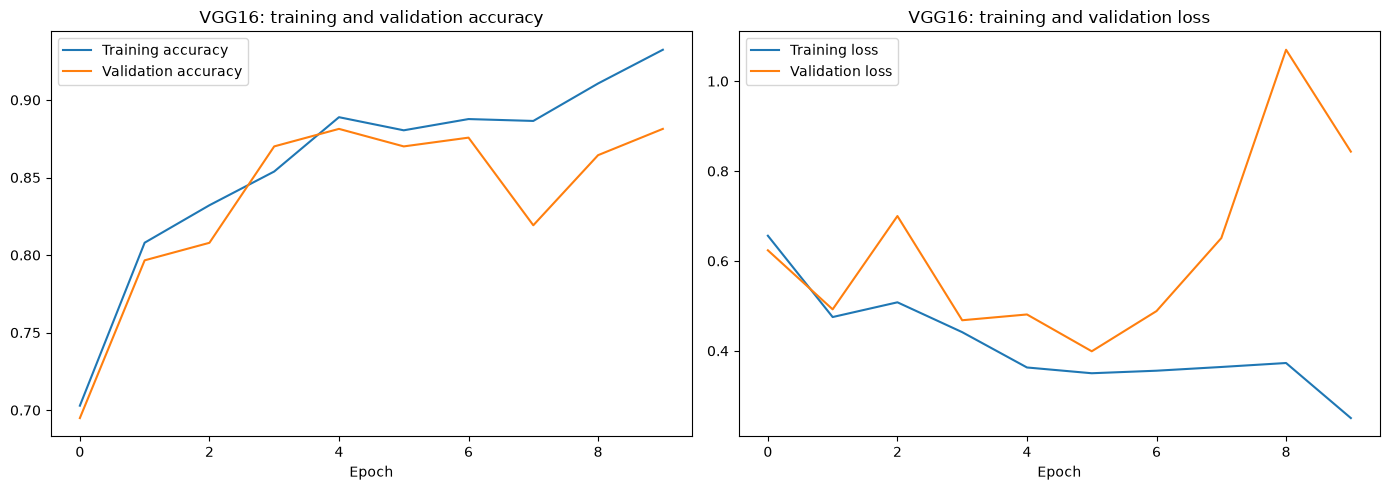

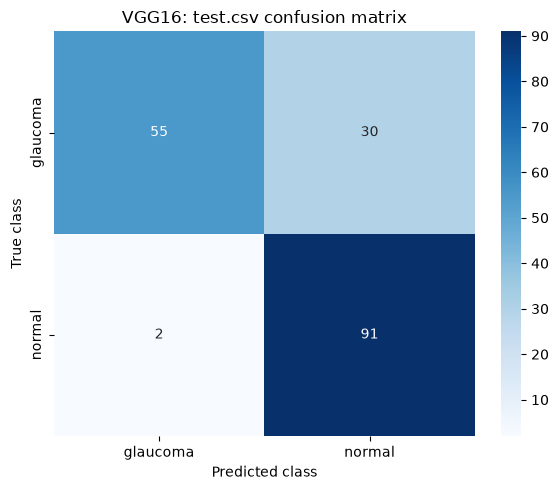

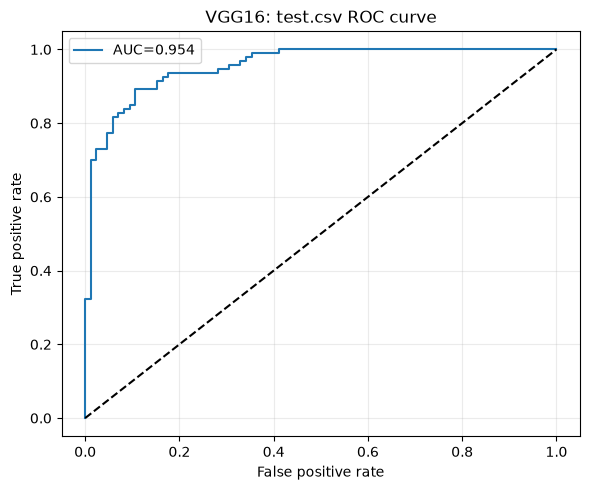

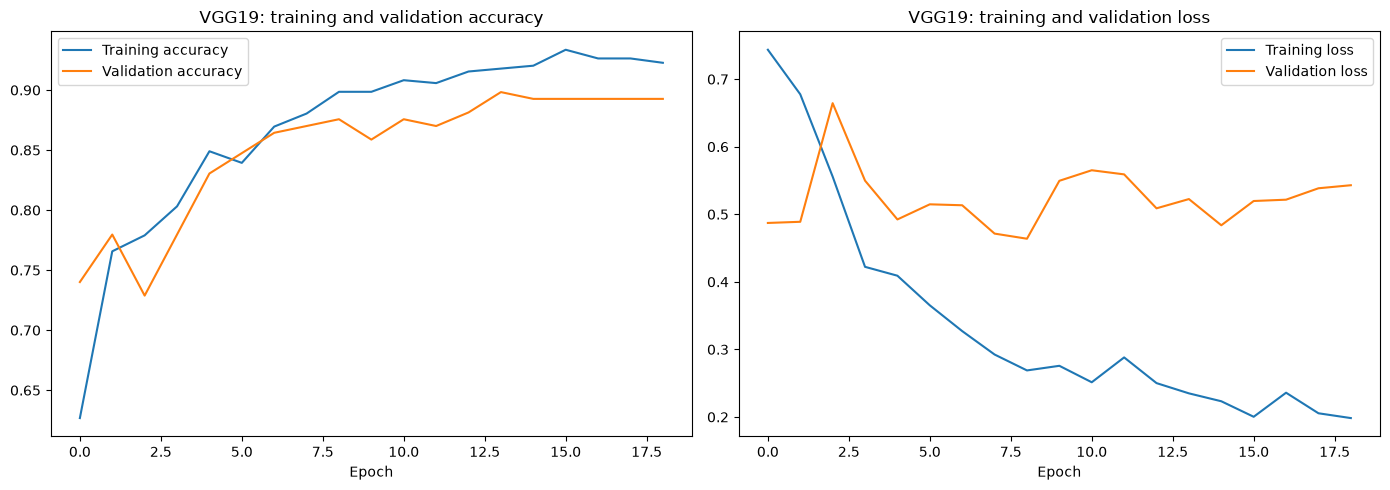

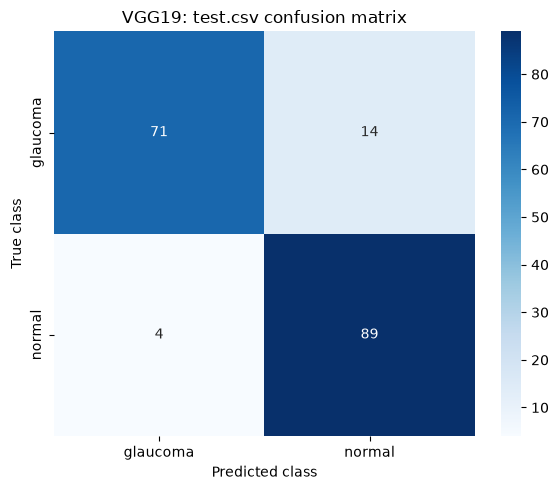

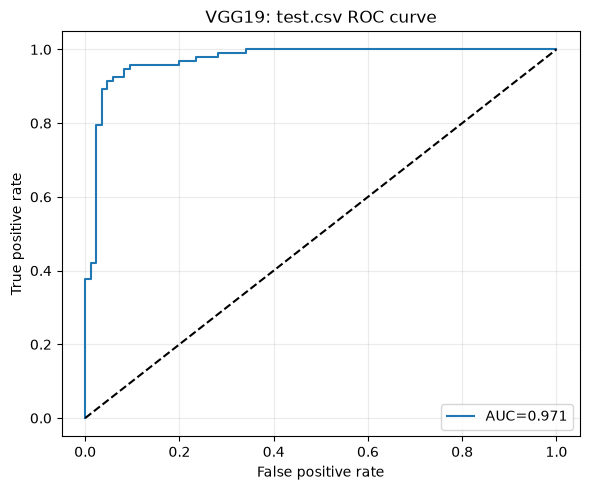

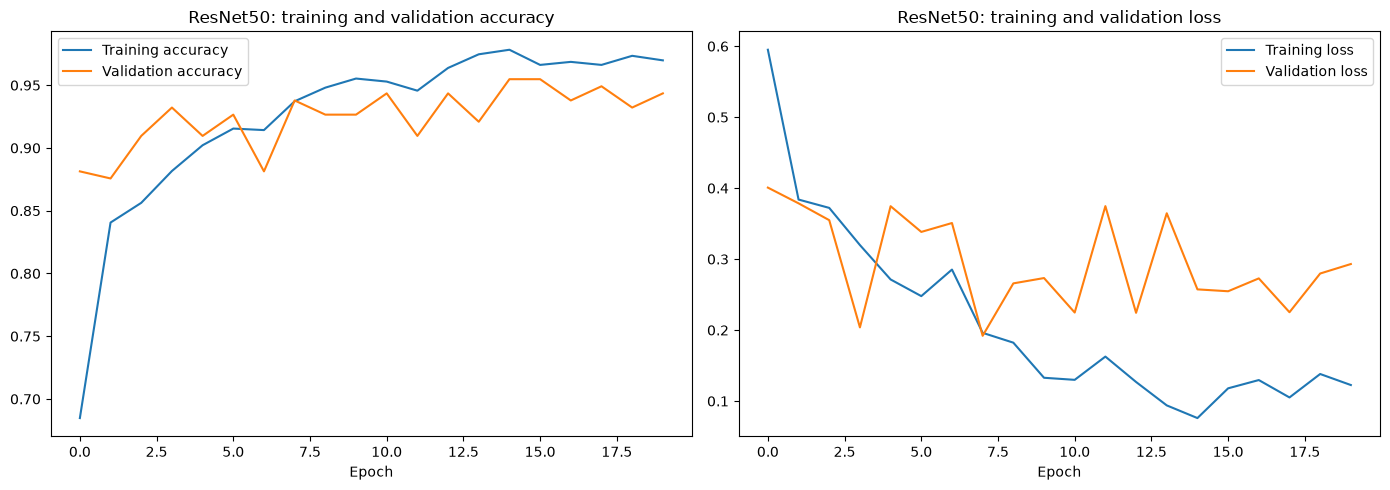

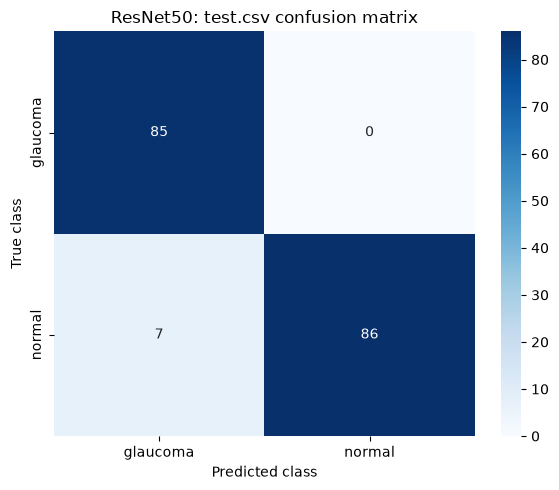

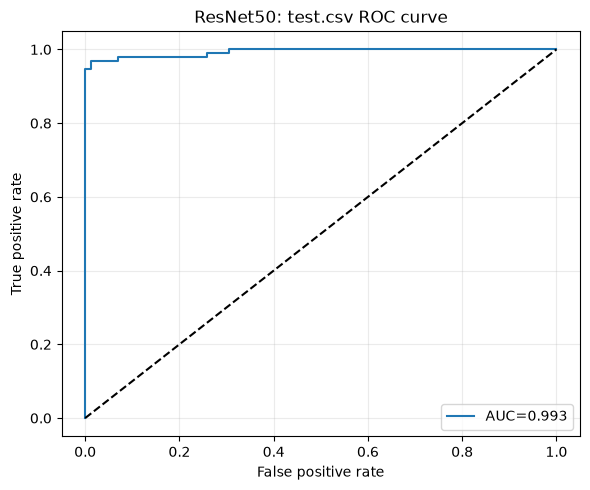

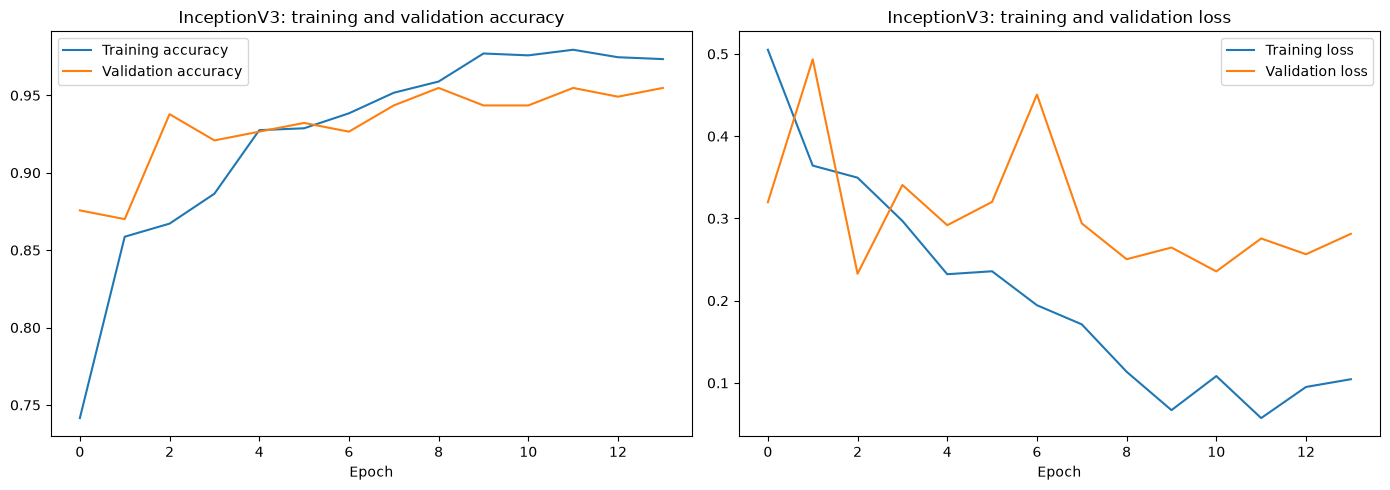

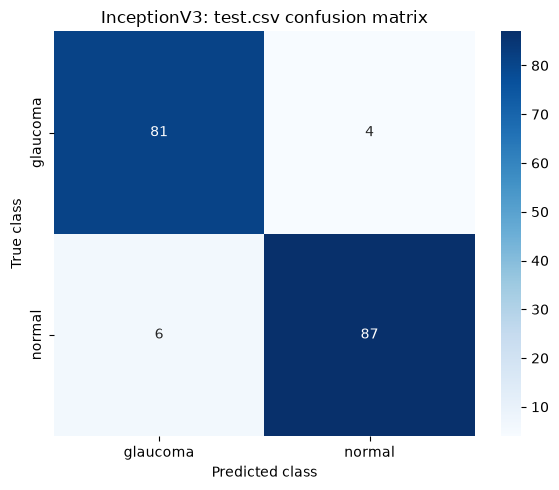

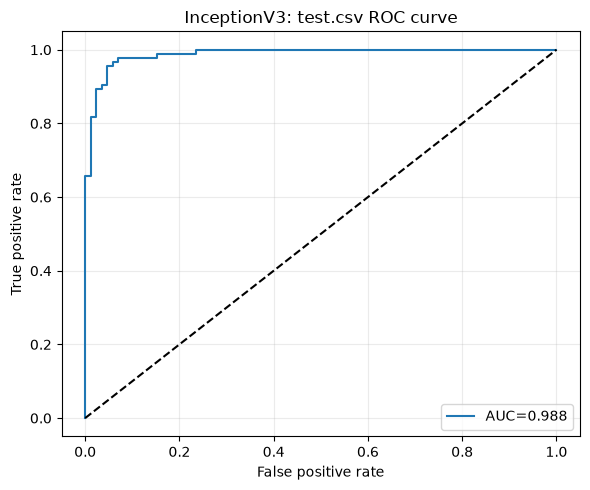

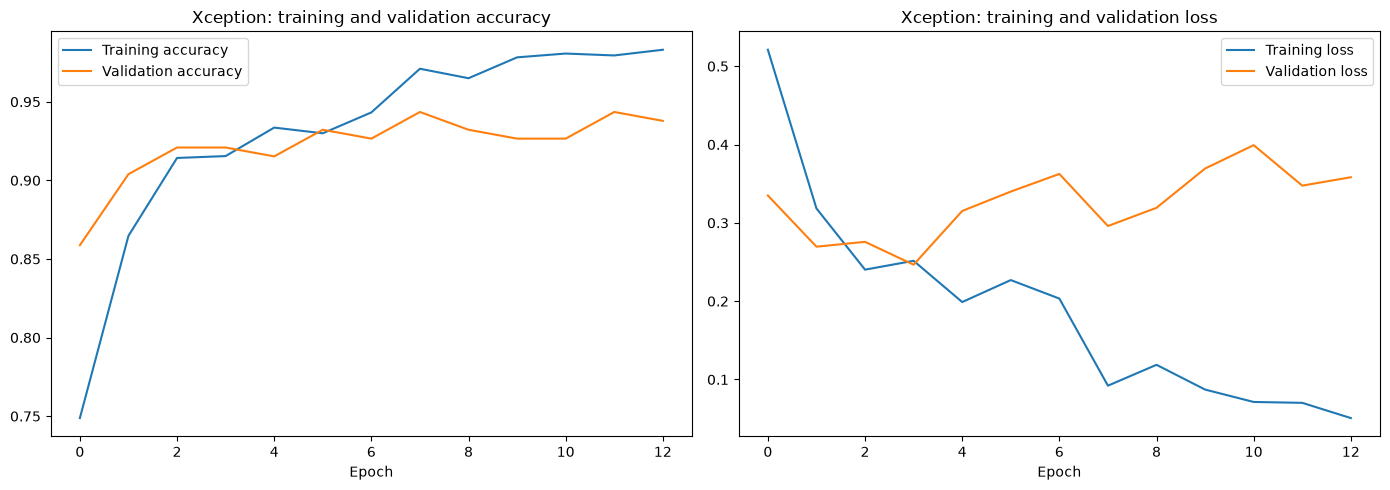

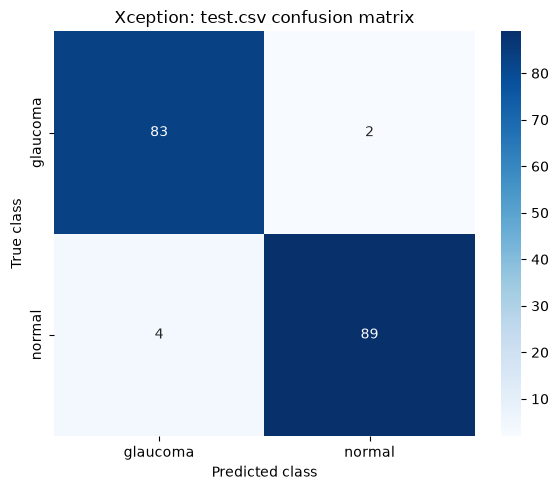

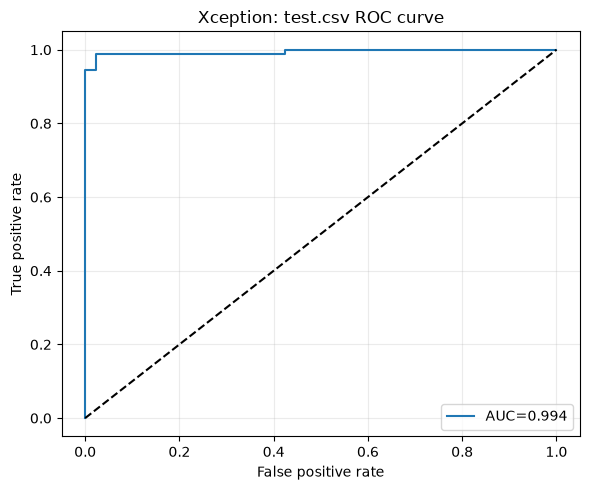

In [24]:
# 12. Train all requested backbones, then evaluate dataset_splits/test.csv
import copy
import gc
import time

import timm

BENCHMARK_MODELS = [
    ("VGG16", 224),
    ("VGG19", 224),
    ("ResNet50", 224),
    ("InceptionV3", 299),
    ("Xception", 299),
]
BENCHMARK_EPOCHS = 100
BENCHMARK_PATIENCE = 5
BENCHMARK_BATCH_SIZE = 8
BENCHMARK_OUTPUT_DIR = DATA_DIR.parent / "backbone_benchmark"
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Remove checkpoints and reports from previous benchmark runs before retraining.
for old_file in BENCHMARK_OUTPUT_DIR.glob("*_best.pt"):
    old_file.unlink()
for old_file in BENCHMARK_OUTPUT_DIR.glob("*_results.csv"):
    old_file.unlink()
for old_file in BENCHMARK_OUTPUT_DIR.glob("*_errors.csv"):
    old_file.unlink()

TEST_CSV_PATH = DATA_DIR.parent / "dataset_splits" / "test.csv"
CSV_TEST_FRAME = pd.read_csv(TEST_CSV_PATH)


def resolve_csv_path(value):
    path = Path(value)
    candidate = path if path.exists() else DATA_DIR.parent / path
    if not candidate.exists():
        raise FileNotFoundError(f"Test image not found: {value}")
    return candidate


CSV_TEST_FRAME["filepath"] = CSV_TEST_FRAME["filepath"].map(resolve_csv_path)


def make_benchmark_transform(image_size, training=False):
    steps = [transforms.Resize((image_size, image_size))]
    if training:
        steps += [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomResizedCrop(image_size, scale=(0.90, 1.0)),
            transforms.ColorJitter(brightness=0.10, contrast=0.10),
        ]
    steps += [
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
    return transforms.Compose(steps)


class BenchmarkDataset(Dataset):
    def __init__(self, frame, image_size, training=False):
        self.frame = frame.reset_index(drop=True)
        self.transform = make_benchmark_transform(image_size, training)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.filepath) as image:
            image = image.convert("RGB")
        image = Image.fromarray(apply_clahe_rgb(np.asarray(image)))
        return self.transform(image), int(row.label)


def make_loader(frame, image_size, training=False):
    return DataLoader(
        BenchmarkDataset(frame, image_size, training),
        batch_size=BENCHMARK_BATCH_SIZE,
        shuffle=training,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def classifier_head(feature_count):
    return nn.Sequential(
        nn.Dropout(0.40),
        nn.Linear(feature_count, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.40),
        nn.Linear(128, NUM_CLASSES),
    )


def build_benchmark_model(model_name):
    if model_name == "VGG16":
        backbone = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        backbone.classifier[-1] = nn.Linear(backbone.classifier[-1].in_features, NUM_CLASSES)
        return backbone.to(DEVICE)
    if model_name == "VGG19":
        backbone = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        backbone.classifier[-1] = nn.Linear(backbone.classifier[-1].in_features, NUM_CLASSES)
        return backbone.to(DEVICE)
    if model_name == "ResNet50":
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        backbone.fc = classifier_head(backbone.fc.in_features)
        return backbone.to(DEVICE)
    if model_name == "InceptionV3":
        backbone = models.inception_v3(
            weights=models.Inception_V3_Weights.DEFAULT,
            aux_logits=True,
        )
        backbone.fc = classifier_head(backbone.fc.in_features)
        return backbone.to(DEVICE)
    if model_name == "Xception":
        feature_extractor = timm.create_model(
            "xception", pretrained=True, num_classes=0, global_pool="avg"
        )
        return nn.Sequential(
            feature_extractor,
            classifier_head(feature_extractor.num_features),
        ).to(DEVICE)
    raise ValueError(f"Unsupported model: {model_name}")


def get_logits(model_instance, images):
    output = model_instance(images)
    return output.logits if hasattr(output, "logits") else output


def evaluate_model(model_instance, loader, collect_predictions=False):
    model_instance.eval()
    total_loss, correct, total = 0.0, 0, 0
    labels_all, probabilities_all = [], []
    with torch.no_grad():
        for images, labels in loader:
            labels = labels.to(DEVICE)
            logits = get_logits(model_instance, images.to(DEVICE))
            probabilities = torch.softmax(logits, dim=1)
            total_loss += nn.functional.cross_entropy(logits, labels).item() * labels.size(0)
            correct += (probabilities.argmax(1) == labels).sum().item()
            total += labels.size(0)
            if collect_predictions:
                labels_all.append(labels.cpu().numpy())
                probabilities_all.append(probabilities.cpu().numpy())
    result = {"loss": total_loss / total, "accuracy": correct / total}
    if collect_predictions:
        result["labels"] = np.concatenate(labels_all)
        result["probabilities"] = np.concatenate(probabilities_all)
    return result


benchmark_results = []
benchmark_outputs = {}
benchmark_errors = []
for model_name, image_size in BENCHMARK_MODELS:
    candidate = None
    try:
        print(f"\n===== {model_name} =====")
        train_loader_b = make_loader(balanced_train_df, image_size, training=True)
        val_loader_b = make_loader(val_df, image_size)
        test_loader_b = make_loader(CSV_TEST_FRAME, image_size)
        candidate = build_benchmark_model(model_name)
        optimizer_b = torch.optim.Adam(candidate.parameters(), lr=1e-4, weight_decay=5e-4)
        scheduler_b = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_b, mode="min", factor=0.3, patience=2, min_lr=1e-7
        )
        criterion_b = nn.CrossEntropyLoss()
        history_b = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
        best_state, best_val_accuracy = None, -1.0
        epochs_without_improvement = 0
        start_time = time.time()

        for epoch in range(BENCHMARK_EPOCHS):
            candidate.train()
            loss_total = correct = total = 0
            for images, labels in train_loader_b:
                labels = labels.to(DEVICE)
                optimizer_b.zero_grad(set_to_none=True)
                logits = get_logits(candidate, images.to(DEVICE))
                loss = criterion_b(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(candidate.parameters(), 1.0)
                optimizer_b.step()
                loss_total += loss.item() * labels.size(0)
                correct += (logits.argmax(1) == labels).sum().item()
                total += labels.size(0)

            train_loss = loss_total / total
            train_accuracy = correct / total
            validation = evaluate_model(candidate, val_loader_b)
            scheduler_b.step(validation["loss"])
            history_b["train_loss"].append(train_loss)
            history_b["train_accuracy"].append(train_accuracy)
            history_b["val_loss"].append(validation["loss"])
            history_b["val_accuracy"].append(validation["accuracy"])
            print(
                f"Epoch {epoch + 1:03d}/{BENCHMARK_EPOCHS} | "
                f"train_acc={train_accuracy:.4f} | val_acc={validation['accuracy']:.4f} | "
                f"train_loss={train_loss:.4f} | val_loss={validation['loss']:.4f}"
            )

            if validation["accuracy"] > best_val_accuracy:
                best_val_accuracy = validation["accuracy"]
                best_state = copy.deepcopy(candidate.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= BENCHMARK_PATIENCE:
                    print("Early stopping")
                    break

        if best_state is None:
            raise RuntimeError(f"{model_name} did not produce a checkpoint")
        candidate.load_state_dict(best_state)
        test_result = evaluate_model(candidate, test_loader_b, collect_predictions=True)
        test_labels = test_result["labels"]
        test_probabilities = test_result["probabilities"]
        test_predictions = test_probabilities.argmax(1)
        test_confusion = confusion_matrix(test_labels, test_predictions, labels=np.arange(NUM_CLASSES))
        test_auc = roc_auc_score(test_labels, test_probabilities[:, 1])
        checkpoint_path = BENCHMARK_OUTPUT_DIR / f"{model_name.lower()}_best.pt"
        torch.save(
            {
                "model_state": candidate.state_dict(),
                "class_names": CLASS_NAMES,
                "model_name": model_name,
                "best_validation_accuracy": best_val_accuracy,
                "test_accuracy": test_result["accuracy"],
                "test_auc": test_auc,
            },
            checkpoint_path,
        )
        print(f"Saved model: {checkpoint_path}")
        benchmark_outputs[model_name] = {
            "history": history_b,
            "labels": test_labels,
            "probabilities": test_probabilities,
            "confusion": test_confusion,
        }
        benchmark_results.append({
            "model": model_name,
            "best_validation_accuracy": best_val_accuracy,
            "test_accuracy": test_result["accuracy"],
            "test_auc": test_auc,
            "test_loss": test_result["loss"],
            "training_seconds": time.time() - start_time,
        })
    except Exception as error:
        print(f"{model_name} failed: {error}")
        benchmark_errors.append({"model": model_name, "error": str(error)})
    finally:
        if candidate is not None:
            del candidate
        gc.collect()
        if torch.cuda.is_available():
            try:
                torch.cuda.empty_cache()
            except RuntimeError:
                pass

results_df = pd.DataFrame(benchmark_results).sort_values(
    ["test_auc", "test_accuracy"], ascending=False
).reset_index(drop=True)
results_df.to_csv(BENCHMARK_OUTPUT_DIR / "backbone_results.csv", index=False)
pd.DataFrame(benchmark_errors).to_csv(BENCHMARK_OUTPUT_DIR / "backbone_errors.csv", index=False)

if results_df.empty:
    raise RuntimeError("No model completed. Check backbone_errors.csv.")

print("\nFinal backbone ranking:")
print(results_df.to_string(index=False))
print(f"Best model: {results_df.iloc[0]['model']}")

for model_name, outputs in benchmark_outputs.items():
    history_b = outputs["history"]
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_b["train_accuracy"], label="Training accuracy")
    axes[0].plot(history_b["val_accuracy"], label="Validation accuracy")
    axes[0].set_title(f"{model_name}: training and validation accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history_b["train_loss"], label="Training loss")
    axes[1].plot(history_b["val_loss"], label="Validation loss")
    axes[1].set_title(f"{model_name}: training and validation loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    figure.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        outputs["confusion"], annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    )
    plt.title(f"{model_name}: test.csv confusion matrix")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.tight_layout()
    plt.show()

    false_positive_rate, true_positive_rate, _ = roc_curve(
        outputs["labels"], outputs["probabilities"][:, 1]
    )
    plt.figure(figsize=(6, 5))
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"AUC={roc_auc_score(outputs['labels'], outputs['probabilities'][:, 1]):.3f}",
    )
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"{model_name}: test.csv ROC curve")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [17]:
# 12b. Generate classification reports for every saved benchmark model
import gc
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import timm
import torch
from PIL import Image
from sklearn.metrics import classification_report
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "eye_disease").exists():
    ROOT_DIR = Path(r"D:\eye disease classification datasets")
DATA_DIR = ROOT_DIR / "eye_disease"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = sorted(folder.name for folder in DATA_DIR.iterdir() if folder.is_dir())
NUM_CLASSES = len(CLASS_NAMES)
NUM_WORKERS = 0
BENCHMARK_BATCH_SIZE = 8
BENCHMARK_MODELS = [
    ("VGG16", 224),
    ("VGG19", 224),
    ("ResNet50", 224),
    ("InceptionV3", 299),
    ("Xception", 299),
]
REPORT_OUTPUT_DIR = ROOT_DIR / "backbone_benchmark"
TEST_CSV_PATH = ROOT_DIR / "dataset_splits" / "test.csv"
CSV_TEST_FRAME = pd.read_csv(TEST_CSV_PATH)
CSV_TEST_FRAME["filepath"] = CSV_TEST_FRAME["filepath"].map(
    lambda value: Path(value) if Path(value).exists() else ROOT_DIR / value
)


def apply_clahe_rgb(rgb_image, clip_limit=2.0, grid_size=(8, 8)):
    rgb_image = np.clip(np.asarray(rgb_image), 0, 255).astype(np.uint8)
    lab_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)
    lightness, a_channel, b_channel = cv2.split(lab_image)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    enhanced_lab = cv2.merge((clahe.apply(lightness), a_channel, b_channel))
    return cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)


def make_report_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])


class ReportDataset(Dataset):
    def __init__(self, frame, image_size):
        self.frame = frame.reset_index(drop=True)
        self.transform = make_report_transform(image_size)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.filepath) as image:
            image = image.convert("RGB")
        image = Image.fromarray(apply_clahe_rgb(np.asarray(image)))
        return self.transform(image), int(row.label)


def classifier_head(feature_count):
    return nn.Sequential(
        nn.Dropout(0.40),
        nn.Linear(feature_count, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.40),
        nn.Linear(128, NUM_CLASSES),
    )


def build_report_model(model_name):
    if model_name == "VGG16":
        model = models.vgg16(weights=None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES)
        return model.to(DEVICE)
    if model_name == "VGG19":
        model = models.vgg19(weights=None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES)
        return model.to(DEVICE)
    if model_name == "ResNet50":
        model = models.resnet50(weights=None)
        model.fc = classifier_head(model.fc.in_features)
        return model.to(DEVICE)
    if model_name == "InceptionV3":
        model = models.inception_v3(weights=None, aux_logits=True)
        model.fc = classifier_head(model.fc.in_features)
        return model.to(DEVICE)
    if model_name == "Xception":
        feature_extractor = timm.create_model(
            "xception", pretrained=False, num_classes=0, global_pool="avg"
        )
        return nn.Sequential(
            feature_extractor,
            classifier_head(feature_extractor.num_features),
        ).to(DEVICE)
    raise ValueError(f"Unsupported model: {model_name}")


report_rows = []
for model_name, image_size in BENCHMARK_MODELS:
    checkpoint_path = REPORT_OUTPUT_DIR / f"{model_name.lower()}_best.pt"
    if not checkpoint_path.exists():
        print(f"Skipping {model_name}: checkpoint not found at {checkpoint_path}")
        continue

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    report_model = build_report_model(model_name)
    report_model.load_state_dict(checkpoint["model_state"])
    test_loader = DataLoader(
        ReportDataset(CSV_TEST_FRAME, image_size),
        batch_size=BENCHMARK_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    labels_all, predictions_all = [], []
    report_model.eval()
    with torch.inference_mode():
        for images, labels in test_loader:
            output = report_model(images.to(DEVICE))
            logits = output.logits if hasattr(output, "logits") else output
            labels_all.extend(labels.numpy())
            predictions_all.extend(logits.argmax(1).cpu().numpy())

    report = classification_report(
        labels_all,
        predictions_all,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        zero_division=0,
        output_dict=True,
    )
    report_frame = pd.DataFrame(report).transpose()
    report_frame.to_csv(
        REPORT_OUTPUT_DIR / f"{model_name.lower()}_classification_report.csv"
    )
    report_frame.insert(0, "model", model_name)
    report_rows.append(report_frame.reset_index(names="class"))

    print(f"\n===== {model_name} classification report =====")
    print(classification_report(
        labels_all,
        predictions_all,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        zero_division=0,
    ))
    del report_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if report_rows:
    pd.concat(report_rows, ignore_index=True).to_csv(
        REPORT_OUTPUT_DIR / "all_classification_reports.csv", index=False
    )
    print(f"Saved reports to: {REPORT_OUTPUT_DIR.resolve()}")
else:
    raise RuntimeError("No benchmark checkpoints were available for report generation.")


===== VGG16 classification report =====
              precision    recall  f1-score   support

    glaucoma       0.96      0.65      0.77        85
      normal       0.75      0.98      0.85        93

    accuracy                           0.82       178
   macro avg       0.86      0.81      0.81       178
weighted avg       0.85      0.82      0.81       178


===== VGG19 classification report =====
              precision    recall  f1-score   support

    glaucoma       0.95      0.84      0.89        85
      normal       0.86      0.96      0.91        93

    accuracy                           0.90       178
   macro avg       0.91      0.90      0.90       178
weighted avg       0.90      0.90      0.90       178


===== ResNet50 classification report =====
              precision    recall  f1-score   support

    glaucoma       0.92      1.00      0.96        85
      normal       1.00      0.92      0.96        93

    accuracy                           0.96       178
  

d:\eye disease classification datasets\venv\Lib\site-packages\torchvision\models\inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(



===== InceptionV3 classification report =====
              precision    recall  f1-score   support

    glaucoma       0.90      0.94      0.92        85
      normal       0.94      0.90      0.92        93

    accuracy                           0.92       178
   macro avg       0.92      0.92      0.92       178
weighted avg       0.92      0.92      0.92       178



d:\eye disease classification datasets\venv\Lib\site-packages\timm\models\_factory.py:175: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(



===== Xception classification report =====
              precision    recall  f1-score   support

    glaucoma       0.95      0.98      0.97        85
      normal       0.98      0.96      0.97        93

    accuracy                           0.97       178
   macro avg       0.97      0.97      0.97       178
weighted avg       0.97      0.97      0.97       178

Saved reports to: D:\eye disease classification datasets\backbone_benchmark


Test accuracy for every trained model:
      model accuracy (%)
MobileNetV2        97.19
   Xception        96.63
   ResNet50        96.07
InceptionV3        94.38
      VGG19        89.89
      VGG16        82.02


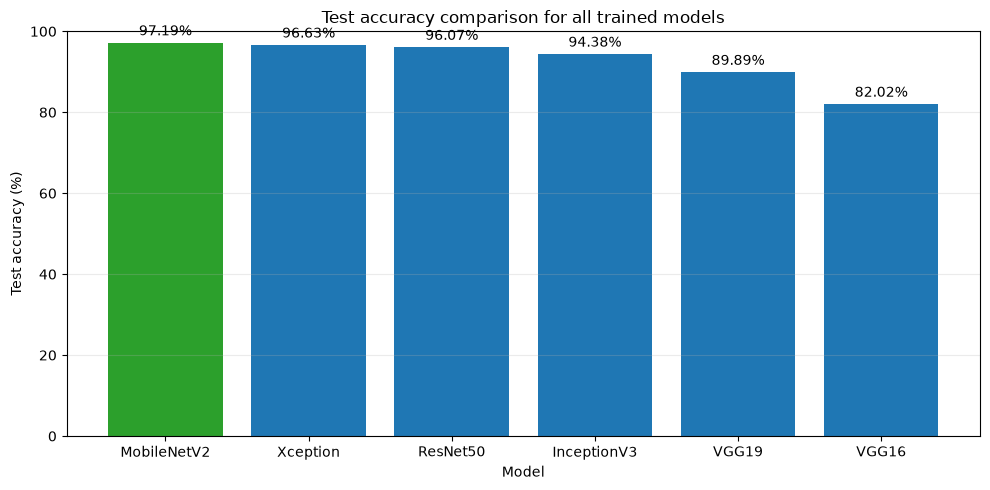

Accuracy chart saved to: d:\eye disease classification datasets\backbone_benchmark\model_accuracy_comparison.png


: 

In [ ]:
# 12c. Show test accuracy for every trained model
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "eye_disease").exists():
    ROOT_DIR = Path(r"D:\eye disease classification datasets")

RESULTS_PATH = ROOT_DIR / "backbone_benchmark" / "backbone_results.csv"
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Benchmark results not found: {RESULTS_PATH}. Run the benchmark training cell first."
    )

accuracy_results = pd.read_csv(RESULTS_PATH)[["model", "test_accuracy"]]

# Include the separately trained MobileNetV2 model when its test predictions exist.
MOBILENET_PREDICTIONS_PATH = ROOT_DIR / "dataset_splits" / "test_predictions.csv"
if MOBILENET_PREDICTIONS_PATH.exists():
    mobilenet_predictions = pd.read_csv(MOBILENET_PREDICTIONS_PATH)
    if "correct" in mobilenet_predictions.columns:
        mobilenet_accuracy = mobilenet_predictions["correct"].mean()
    else:
        mobilenet_accuracy = (
            mobilenet_predictions["true_label"]
            == mobilenet_predictions["predicted_label"]
        ).mean()
    accuracy_results = pd.concat(
        [
            accuracy_results,
            pd.DataFrame({"model": ["MobileNetV2"], "test_accuracy": [mobilenet_accuracy]}),
        ],
        ignore_index=True,
    )

accuracy_results = accuracy_results.sort_values(
    "test_accuracy", ascending=False
).reset_index(drop=True)
accuracy_results["test_accuracy_percent"] = accuracy_results["test_accuracy"] * 100

print("Test accuracy for every trained model:")
print(
    accuracy_results[["model", "test_accuracy_percent"]]
    .rename(columns={"test_accuracy_percent": "accuracy (%)"})
    .to_string(index=False, formatters={"accuracy (%)": "{:.2f}".format})
)

plt.figure(figsize=(10, 5))
bar_colors = ["#2ca02c" if index == 0 else "#1f77b4" for index in range(len(accuracy_results))]
bars = plt.bar(
    accuracy_results["model"],
    accuracy_results["test_accuracy_percent"],
    color=bar_colors,
)
plt.ylim(0, 100)
plt.ylabel("Test accuracy (%)")
plt.xlabel("Model")
plt.title("Test accuracy comparison for all trained models")
plt.grid(axis="y", alpha=0.25)

for bar, accuracy in zip(bars, accuracy_results["test_accuracy_percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
accuracy_plot_path = ROOT_DIR / "backbone_benchmark" / "model_accuracy_comparison.png"
plt.savefig(accuracy_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Accuracy chart saved to: {accuracy_plot_path}")

Model: InceptionV3
Checkpoint: d:\eye disease classification datasets\backbone_benchmark\inceptionv3_best.pt
Device: cuda


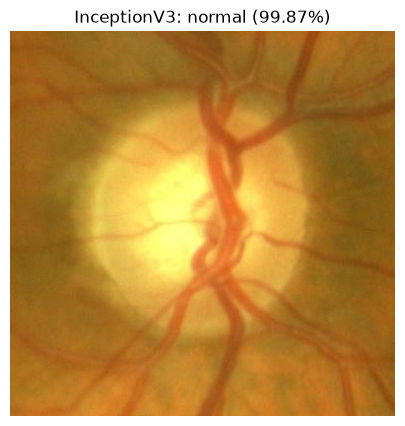

{'model': 'InceptionV3', 'image': 'd:\\eye disease classification datasets\\n3.jpg', 'predicted_class': 'normal', 'confidence': 0.9986995458602905, 'probabilities': {'glaucoma': 0.0013004414504393935, 'normal': 0.9986995458602905}}


In [15]:
# 13. Predict an unseen image with any trained benchmark model
from pathlib import Path
import gc

import cv2
import numpy as np
import timm
import torch
from PIL import Image
from torch import nn
from torchvision import models, transforms
import matplotlib.pyplot as plt

# These settings make this cell runnable after a kernel restart as well.
ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "eye_disease").exists():
    ROOT_DIR = Path(r"D:\eye disease classification datasets")
DATA_DIR = ROOT_DIR / "eye_disease"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "InceptionV3"  # VGG16, VGG19, ResNet50, InceptionV3, or Xception
UNSEEN_IMAGE_PATH = ROOT_DIR / "n3.jpg"  # Change this to another existing image.

SUPPORTED_MODELS = {
    "VGG16": 224,
    "VGG19": 224,
    "ResNet50": 224,
    "InceptionV3": 299,
    "Xception": 299,
}

if MODEL_NAME not in SUPPORTED_MODELS:
    raise ValueError(
        f"Unsupported model: {MODEL_NAME}. Choose one of {list(SUPPORTED_MODELS)}."
    )

checkpoint_path = ROOT_DIR / "backbone_benchmark" / f"{MODEL_NAME.lower()}_best.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path.resolve()}")

if not UNSEEN_IMAGE_PATH.exists():
    raise FileNotFoundError(
        f"Unseen image not found: {UNSEEN_IMAGE_PATH.resolve()}. "
        "Update UNSEEN_IMAGE_PATH to the image you want to classify."
    )


def apply_clahe_rgb(rgb_image, clip_limit=2.0, grid_size=(8, 8)):
    """Apply the same Lab-channel CLAHE preprocessing used during training."""
    rgb_image = np.clip(np.asarray(rgb_image), 0, 255).astype(np.uint8)
    lab_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)
    lightness, a_channel, b_channel = cv2.split(lab_image)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    enhanced_lightness = clahe.apply(lightness)
    enhanced_lab = cv2.merge((enhanced_lightness, a_channel, b_channel))
    return cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)


benchmark_checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False,
)
class_names_for_prediction = benchmark_checkpoint["class_names"]


def make_classifier_head(feature_count):
    return nn.Sequential(
        nn.Dropout(0.40),
        nn.Linear(feature_count, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.40),
        nn.Linear(128, len(class_names_for_prediction)),
    )


def build_prediction_model(model_name):
    if model_name == "VGG16":
        prediction_model = models.vgg16(weights=None)
        prediction_model.classifier[-1] = nn.Linear(
            prediction_model.classifier[-1].in_features,
            len(class_names_for_prediction),
        )
        return prediction_model
    if model_name == "VGG19":
        prediction_model = models.vgg19(weights=None)
        prediction_model.classifier[-1] = nn.Linear(
            prediction_model.classifier[-1].in_features,
            len(class_names_for_prediction),
        )
        return prediction_model
    if model_name == "ResNet50":
        prediction_model = models.resnet50(weights=None)
        prediction_model.fc = make_classifier_head(prediction_model.fc.in_features)
        return prediction_model
    if model_name == "InceptionV3":
        prediction_model = models.inception_v3(weights=None, aux_logits=True)
        prediction_model.fc = make_classifier_head(prediction_model.fc.in_features)
        return prediction_model
    if model_name == "Xception":
        feature_extractor = timm.create_model(
            "xception", pretrained=False, num_classes=0, global_pool="avg"
        )
        return nn.Sequential(
            feature_extractor,
            make_classifier_head(feature_extractor.num_features),
        )
    raise ValueError(f"Unsupported model: {model_name}")


benchmark_model = build_prediction_model(MODEL_NAME)
benchmark_model.load_state_dict(benchmark_checkpoint["model_state"])
benchmark_model = benchmark_model.to(DEVICE)
benchmark_model.eval()

# Inference matches BenchmarkDataset: CLAHE -> resize -> tensor -> ImageNet normalization.
image_size = SUPPORTED_MODELS[MODEL_NAME]
benchmark_preprocess = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def predict_unseen_image(image_path):
    image_path = Path(image_path)
    with Image.open(image_path) as image:
        original_image = image.convert("RGB")
        display_image = original_image.copy()
        enhanced_image = Image.fromarray(apply_clahe_rgb(np.asarray(original_image)))

    input_tensor = benchmark_preprocess(enhanced_image).unsqueeze(0).to(DEVICE)
    with torch.inference_mode():
        output = benchmark_model(input_tensor)
        logits = output.logits if hasattr(output, "logits") else output
        probabilities = torch.softmax(logits, dim=1)[0]

    predicted_index = int(probabilities.argmax().item())
    result = {
        "model": MODEL_NAME,
        "image": str(image_path),
        "predicted_class": class_names_for_prediction[predicted_index],
        "confidence": float(probabilities[predicted_index].item()),
        "probabilities": {
            class_name: float(probability)
            for class_name, probability in zip(
                class_names_for_prediction,
                probabilities.cpu().tolist(),
            )
        },
    }

    plt.figure(figsize=(5, 5))
    plt.imshow(display_image)
    plt.axis("off")
    plt.title(
        f"{MODEL_NAME}: {result['predicted_class']} "
        f"({result['confidence'] * 100:.2f}%)"
    )
    plt.show()
    return result


print(f"Model: {MODEL_NAME}")
print(f"Checkpoint: {checkpoint_path}")
print(f"Device: {DEVICE}")
print(predict_unseen_image(UNSEEN_IMAGE_PATH))